# Notebook 05 — Enhanced 3D ResUNet Training

This notebook trains the exact Enhanced 3D ResUNet architecture validated in Notebook 04.

**Tasks**
- Binary rib-fracture segmentation
- Five-class fracture classification

**Important:** the current RibFrac128 development case is a pipeline test only. Final thesis training must use the patient-level train/validation structure produced by Notebook 03.

**Notebook 06 persistence:** all model, history, metric, configuration, and Kaggle metadata files are saved under `/kaggle/working/training_results/`.


In [1]:
# ============================================================
# CELL 1 — IMPORTS AND REPRODUCIBILITY
# ============================================================
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Seed:", SEED)


TensorFlow: 2.20.0
Seed: 42


In [2]:
# ============================================================
# CELL 2 — GPU CONFIGURATION
# ============================================================
gpus = tf.config.list_physical_devices("GPU")
print("Number of GPUs:", len(gpus))

if gpus:
    for gpu in gpus:
        print(gpu)
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as error:
        print("GPU configuration warning:", error)
else:
    print("WARNING: No GPU detected.")


Number of GPUs: 2
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
GPU memory growth enabled.


## 1. Persistent input and output locations

Change only these paths if your published Kaggle Dataset slugs differ.


In [3]:
# ============================================================
# CELL 3 — PERSISTENT DATASET PATHS
# ============================================================
from pathlib import Path

PATCH_DATASET_ROOT = Path("/kaggle/input/datasets/waboke/ribfrac-patch-dataset")

MODEL_ARTIFACT_ROOT = Path("/kaggle/input/datasets/waboke/model-artifacts")

OUTPUT_ROOT = Path("/kaggle/working/training_results")

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

print("Patch dataset:")
print(PATCH_DATASET_ROOT)

print()
print("Model artifacts:")
print(MODEL_ARTIFACT_ROOT)

print()
print("Training output:")
print(OUTPUT_ROOT)


Patch dataset:
/kaggle/input/datasets/waboke/ribfrac-patch-dataset

Model artifacts:
/kaggle/input/datasets/waboke/model-artifacts

Training output:
/kaggle/working/training_results


In [4]:
from pathlib import Path

MODEL_ARTIFACT_ROOT = Path("/kaggle/input/datasets/waboke/model-artifacts")

print("Contents of model-artifacts:")
print("=" * 60)

for path in MODEL_ARTIFACT_ROOT.rglob("*"):
    print(path)

Contents of model-artifacts:
/kaggle/input/datasets/waboke/model-artifacts/model_config.json
/kaggle/input/datasets/waboke/model-artifacts/enhanced_3d_resunet_multitask.keras


In [5]:
# ============================================================
# CELL 4 — VERIFY PERSISTENT INPUTS
# ============================================================
MODEL_PATH = MODEL_ARTIFACT_ROOT / "enhanced_3d_resunet_multitask.keras"
MODEL_CONFIG_PATH = MODEL_ARTIFACT_ROOT / "model_config.json"

print("Model file exists:", MODEL_PATH.exists())
print("Model config exists:", MODEL_CONFIG_PATH.exists())

print()
print("Model path:")
print(MODEL_PATH)

print()
print("Config path:")
print(MODEL_CONFIG_PATH)

Model file exists: True
Model config exists: True

Model path:
/kaggle/input/datasets/waboke/model-artifacts/enhanced_3d_resunet_multitask.keras

Config path:
/kaggle/input/datasets/waboke/model-artifacts/model_config.json


In [8]:
import tensorflow as tf

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("Model loaded successfully.")
print("Input shape:", model.input_shape)
print("Output shapes:")

for output in model.outputs:
    print(output.shape)

I0000 00:00:1791275035.453930      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791275035.457630      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model loaded successfully.
Input shape: (None, 64, 64, 64, 1)
Output shapes:
(None, 5)
(None, 64, 64, 64, 1)


In [9]:
# ============================================================
# CELL 5 — LOAD MODEL CONFIGURATION
# ============================================================
with open(MODEL_CONFIG_PATH, "r", encoding="utf-8") as f:
    model_config = json.load(f)

PATCH_SIZE = tuple(model_config["patch_size"])
NUM_CLASSES = int(model_config["num_classes"])
CLASS_NAMES = model_config["class_names"]
BASE_FILTERS = int(model_config["base_filters"])
DEPTH = int(model_config["depth"])
DROPOUT_RATE = float(model_config["dropout_rate"])

print("Patch size:", PATCH_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Class names:", CLASS_NAMES)
print("Base filters:", BASE_FILTERS)
print("Depth:", DEPTH)
print("Dropout:", DROPOUT_RATE)


Patch size: (64, 64, 64)
Number of classes: 5
Class names: {'0': 'background', '1': 'displaced', '2': 'non-displaced', '3': 'buckle', '4': 'segmental'}
Base filters: 16
Depth: 4
Dropout: 0.2


## 2. Locate training data

The notebook supports both the current `RibFrac128` development case and the final patient-level `train/validation/test` structure. The final experiment must use patient-level splits created before patch extraction.


In [10]:
# ============================================================
# CELL 6 — DATASET STRUCTURE DETECTION
# ============================================================
RIBFRAC128_ROOT = PATCH_DATASET_ROOT / "RibFrac128"
FINAL_TRAIN_ROOT = PATCH_DATASET_ROOT / "train"
FINAL_VAL_ROOT = PATCH_DATASET_ROOT / "validation"
FINAL_TEST_ROOT = PATCH_DATASET_ROOT / "test"

USE_FINAL_SPLITS = FINAL_TRAIN_ROOT.exists() and FINAL_VAL_ROOT.exists()

print("Final patient-level train/validation structure:", USE_FINAL_SPLITS)
print("Development case exists:", RIBFRAC128_ROOT.exists())


Final patient-level train/validation structure: False
Development case exists: True


In [11]:
# ============================================================
# CELL 7 — DEVELOPMENT DATA LOADER
# ============================================================
def load_development_case(root):
    paths = [root / "X.npy", root / "Y_seg.npy", root / "Y_class.npy"]
    for path in paths:
        if not path.exists():
            raise FileNotFoundError(f"Missing file: {path}")
    return (
        np.load(paths[0], mmap_mode="r"),
        np.load(paths[1], mmap_mode="r"),
        np.load(paths[2], mmap_mode="r"),
    )

if not USE_FINAL_SPLITS:
    X, Y_seg, Y_class = load_development_case(RIBFRAC128_ROOT)
    print("X:", X.shape, X.dtype)
    print("Y_seg:", Y_seg.shape, Y_seg.dtype)
    print("Y_class:", Y_class.shape, Y_class.dtype)


X: (8, 64, 64, 64, 1) float32
Y_seg: (8, 64, 64, 64, 1) uint8
Y_class: (8,) int64


In [12]:
# ============================================================
# CELL 8 — DEVELOPMENT DATA VALIDATION
# ============================================================
if not USE_FINAL_SPLITS:
    assert X.ndim == 5 and Y_seg.ndim == 5 and Y_class.ndim == 1
    assert X.shape[0] == Y_seg.shape[0] == Y_class.shape[0]
    assert X.shape[1:] == (*PATCH_SIZE, 1)
    assert Y_seg.shape[1:] == (*PATCH_SIZE, 1)
    assert set(np.unique(Y_seg).tolist()).issubset({0, 1})
    assert set(np.unique(Y_class).tolist()).issubset(set(range(NUM_CLASSES)))
    print("Development data validation: PASS")
    print("Patches:", len(X))
    print("Classes:", np.unique(Y_class))


Development data validation: PASS
Patches: 8
Classes: [0 3]


In [13]:
# ============================================================
# CELL 9 — FINAL PATIENT-LEVEL DATA LOADER
# ============================================================
def discover_patient_cases(split_root):
    cases = []
    for patient_dir in sorted(split_root.iterdir()):
        if not patient_dir.is_dir():
            continue
        needed = [patient_dir / "X.npy", patient_dir / "Y_seg.npy", patient_dir / "Y_class.npy"]
        if all(p.exists() for p in needed):
            cases.append(patient_dir)
    return cases

def load_split_cases(split_root):
    patient_dirs = discover_patient_cases(split_root)
    if not patient_dirs:
        raise FileNotFoundError(f"No patient patch directories found under {split_root}")

    X_parts, Y_seg_parts, Y_class_parts, patient_ids = [], [], [], []

    for patient_dir in patient_dirs:
        x = np.load(patient_dir / "X.npy")
        y_seg = np.load(patient_dir / "Y_seg.npy")
        y_class = np.load(patient_dir / "Y_class.npy").reshape(-1)

        if len(x) == 0:
            continue

        X_parts.append(np.asarray(x, dtype=np.float32))
        Y_seg_parts.append(np.asarray(y_seg, dtype=np.float32))
        Y_class_parts.append(np.asarray(y_class, dtype=np.int32))
        patient_ids.extend([patient_dir.name] * len(x))

    if not X_parts:
        raise ValueError(f"No patches found in {split_root}")

    return (
        np.concatenate(X_parts),
        np.concatenate(Y_seg_parts),
        np.concatenate(Y_class_parts),
        np.asarray(patient_ids),
    )


In [14]:
# ============================================================
# CELL 10 — SELECT TRAINING MODE
# ============================================================
if USE_FINAL_SPLITS:
    X_train, Y_seg_train, Y_class_train, train_patient_ids = load_split_cases(FINAL_TRAIN_ROOT)
    X_val, Y_seg_val, Y_class_val, val_patient_ids = load_split_cases(FINAL_VAL_ROOT)

    overlap = set(train_patient_ids) & set(val_patient_ids)
    assert not overlap, f"Patient leakage detected: {overlap}"

    SMOKE_TEST_ONLY = False

    print("FINAL PATIENT-LEVEL DATASET")
    print("Training patches:", len(X_train))
    print("Validation patches:", len(X_val))
    print("Training patients:", len(np.unique(train_patient_ids)))
    print("Validation patients:", len(np.unique(val_patient_ids)))
else:
    X_all = np.asarray(X, dtype=np.float32)
    Y_seg_all = np.asarray(Y_seg, dtype=np.float32)
    Y_class_all = np.asarray(Y_class, dtype=np.int32).reshape(-1)

    indices = np.arange(len(X_all))
    rng = np.random.default_rng(SEED)
    rng.shuffle(indices)

    split_index = max(1, min(int(0.75 * len(indices)), len(indices) - 1))
    train_idx = indices[:split_index]
    val_idx = indices[split_index:]

    X_train = X_all[train_idx]
    Y_seg_train = Y_seg_all[train_idx]
    Y_class_train = Y_class_all[train_idx]

    X_val = X_all[val_idx]
    Y_seg_val = Y_seg_all[val_idx]
    Y_class_val = Y_class_all[val_idx]

    SMOKE_TEST_ONLY = True

    print("DEVELOPMENT / SMOKE-TEST DATASET")
    print("Training patches:", len(X_train))
    print("Validation patches:", len(X_val))
    print("WARNING: Do not report these results as final research results.")


DEVELOPMENT / SMOKE-TEST DATASET
Training patches: 6
Validation patches: 2


In [15]:
# ============================================================
# CELL 11 — FINAL ARRAY VALIDATION
# ============================================================
for name, arr in {
    "X_train": X_train, "Y_seg_train": Y_seg_train, "Y_class_train": Y_class_train,
    "X_val": X_val, "Y_seg_val": Y_seg_val, "Y_class_val": Y_class_val,
}.items():
    print(name, arr.shape, arr.dtype)

assert X_train.shape[1:] == (*PATCH_SIZE, 1)
assert X_val.shape[1:] == (*PATCH_SIZE, 1)
assert Y_seg_train.shape[1:] == (*PATCH_SIZE, 1)
assert Y_seg_val.shape[1:] == (*PATCH_SIZE, 1)
assert set(np.unique(Y_seg_train).tolist()).issubset({0, 1})
assert set(np.unique(Y_seg_val).tolist()).issubset({0, 1})
assert set(np.unique(Y_class_train).tolist()).issubset(set(range(NUM_CLASSES)))
assert set(np.unique(Y_class_val).tolist()).issubset(set(range(NUM_CLASSES)))

print("Training-array validation: PASS")


X_train (6, 64, 64, 64, 1) float32
Y_seg_train (6, 64, 64, 64, 1) float32
Y_class_train (6,) int32
X_val (2, 64, 64, 64, 1) float32
Y_seg_val (2, 64, 64, 64, 1) float32
Y_class_val (2,) int32
Training-array validation: PASS


In [16]:
# ============================================================
# CELL 12 — CLASS DISTRIBUTION
# ============================================================
def print_class_distribution(name, y):
    print(name)
    print("-" * 55)
    total = len(y)
    for class_id in range(NUM_CLASSES):
        count = int(np.sum(y == class_id))
        pct = 100 * count / total if total else 0
        class_name = CLASS_NAMES.get(str(class_id), CLASS_NAMES.get(class_id, f"class_{class_id}"))
        print(f"{class_id}: {class_name:16s} {count:8d} ({pct:6.2f}%)")
    print()

print_class_distribution("Training classification distribution", Y_class_train)
print_class_distribution("Validation classification distribution", Y_class_val)


Training classification distribution
-------------------------------------------------------
0: background              3 ( 50.00%)
1: displaced               0 (  0.00%)
2: non-displaced           0 (  0.00%)
3: buckle                  3 ( 50.00%)
4: segmental               0 (  0.00%)

Validation classification distribution
-------------------------------------------------------
0: background              1 ( 50.00%)
1: displaced               0 (  0.00%)
2: non-displaced           0 (  0.00%)
3: buckle                  1 ( 50.00%)
4: segmental               0 (  0.00%)



## 3. Load the exact model from Notebook 04


In [17]:
# ============================================================
# CELL 13 — LOAD MODEL
# ============================================================
model = keras.models.load_model(MODEL_PATH, compile=False)

print("Model loaded:", model.name)
print("Input:", model.input_shape)
print("Outputs:", model.output_shape)


Model loaded: Enhanced_3D_ResUNet_MultiTask
Input: (None, 64, 64, 64, 1)
Outputs: [(None, 5), (None, 64, 64, 64, 1)]


In [20]:
# ============================================================
# CELL 14 — ARCHITECTURE VALIDATION
# ============================================================

assert model.input_shape == (
    None, 64, 64, 64, 1
)

print("Model input shape:", model.input_shape)
print("Model output shapes:", model.output_shape)

# Keras stores the output shapes as a list.
# In the loaded model:
#   output 0 = classification
#   output 1 = segmentation

assert isinstance(model.output_shape, list)
assert len(model.output_shape) == 2

# Classification output
assert model.output_shape[0] == (
    None, 5
)

# Segmentation output
assert model.output_shape[1] == (
    None, 64, 64, 64, 1
)

print()
print(
    "Classification output:",
    model.output_shape[0]
)

print(
    "Segmentation output:",
    model.output_shape[1]
)

print()
print("Model architecture validation: PASS")

Model input shape: (None, 64, 64, 64, 1)
Model output shapes: [(None, 5), (None, 64, 64, 64, 1)]

Classification output: (None, 5)
Segmentation output: (None, 64, 64, 64, 1)

Model architecture validation: PASS


## 4. Metrics


In [21]:
# ============================================================
# CELL 15 — DICE COEFFICIENT
# ============================================================
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred >= 0.5, tf.float32)
    axes = [1, 2, 3, 4]
    intersection = tf.reduce_sum(y_true * y_pred, axis=axes)
    denominator = tf.reduce_sum(y_true, axis=axes) + tf.reduce_sum(y_pred, axis=axes)
    return tf.reduce_mean((2.0 * intersection + smooth) / (denominator + smooth))


In [22]:
# ============================================================
# CELL 16 — IoU COEFFICIENT
# ============================================================
def iou_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred >= 0.5, tf.float32)
    axes = [1, 2, 3, 4]
    intersection = tf.reduce_sum(y_true * y_pred, axis=axes)
    union = tf.reduce_sum(y_true, axis=axes) + tf.reduce_sum(y_pred, axis=axes) - intersection
    return tf.reduce_mean((intersection + smooth) / (union + smooth))


## 5. Training configuration


In [23]:
# ============================================================
# CELL 17 — TRAINING HYPERPARAMETERS
# ============================================================
BATCH_SIZE = 1
EPOCHS = 50
LEARNING_RATE = 1e-4

SEGMENTATION_LOSS_WEIGHT = 1.0
CLASSIFICATION_LOSS_WEIGHT = 1.0

print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)


Batch size: 1
Epochs: 50
Learning rate: 0.0001


In [25]:
# ============================================================
# CELL 18 — COMPILE MODEL
# ============================================================
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss={
        "segmentation_output": keras.losses.BinaryCrossentropy(),
        "classification_output": keras.losses.SparseCategoricalCrossentropy(),
    },
    loss_weights={
        "segmentation_output": SEGMENTATION_LOSS_WEIGHT,
        "classification_output": CLASSIFICATION_LOSS_WEIGHT,
    },
    metrics={
        "segmentation_output": [
            keras.metrics.BinaryAccuracy(name="seg_accuracy"),
            dice_coefficient,
            iou_coefficient,
        ],
        "classification_output": [
            keras.metrics.SparseCategoricalAccuracy(name="cls_accuracy"),
        ],
    },
)

print("Model compilation: PASS")


Model compilation: PASS


## 6. Persistent training artifacts

Notebook 05 saves everything Notebook 06 needs into one directory:

```text
training_results/
├── checkpoints/
│   └── best_enhanced_3d_resunet.keras
├── final_enhanced_3d_resunet_multitask.keras
├── training_history.csv
├── training_history.npy
├── validation_metrics.json
├── experiment_config.json
└── dataset-metadata.json
```

The final cell also prepares the directory for publishing as the persistent Kaggle Dataset:
`waboke/ribfrac-resunet-training-results`.


In [26]:
# ============================================================
# CELL 19 — OUTPUT PATHS
# ============================================================
CHECKPOINT_ROOT = OUTPUT_ROOT / "checkpoints"
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = CHECKPOINT_ROOT / "best_enhanced_3d_resunet.keras"
FINAL_MODEL_PATH = OUTPUT_ROOT / "final_enhanced_3d_resunet_multitask.keras"
HISTORY_CSV_PATH = OUTPUT_ROOT / "training_history.csv"
HISTORY_NPY_PATH = OUTPUT_ROOT / "training_history.npy"
METRICS_PATH = OUTPUT_ROOT / "validation_metrics.json"
CONFIG_OUTPUT_PATH = OUTPUT_ROOT / "experiment_config.json"

print("Output root:", OUTPUT_ROOT)


Output root: /kaggle/working/training_results


In [27]:
# ============================================================
# CELL 20 — CALLBACKS
# ============================================================
checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=str(BEST_MODEL_PATH),
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

early_stopping_callback = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=7,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr_callback = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1,
)

csv_logger_callback = keras.callbacks.CSVLogger(str(HISTORY_CSV_PATH))

print("Callbacks configured.")


Callbacks configured.


## 7. Train the model


In [28]:
# ============================================================
# CELL 21 — MODEL TRAINING
# ============================================================
print("=" * 70)
print("STARTING ENHANCED 3D RESUNET TRAINING")
print("=" * 70)

history = model.fit(
    X_train,
    {
        "segmentation_output": Y_seg_train,
        "classification_output": Y_class_train,
    },
    validation_data=(
        X_val,
        {
            "segmentation_output": Y_seg_val,
            "classification_output": Y_class_val,
        },
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[
        checkpoint_callback,
        early_stopping_callback,
        reduce_lr_callback,
        csv_logger_callback,
    ],
    verbose=1,
)

print("=" * 70)
print("TRAINING COMPLETED")
print("=" * 70)


STARTING ENHANCED 3D RESUNET TRAINING
Epoch 1/50
1/6 ━━━━━━━━━━━━━━━━━━━━ 2:31 30s/step - classification_output_cls_accuracy: 0.0000e+00 - classification_output_loss: 1.7121 - loss: 2.5482 - segmentation_output_dice_coefficient: 0.0056 - segmentation_output_iou_coefficient: 0.0028 - segmentation_output_loss: 0.8361 - segmentation_output_seg_accuracy: 0.5402

I0000 00:00:1791275449.912306     147 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - classification_output_cls_accuracy: 0.0611 - classification_output_loss: 2.1374 - loss: 2.9525 - segmentation_output_dice_coefficient: 0.0038 - segmentation_output_iou_coefficient: 0.0019 - segmentation_output_loss: 0.8152 - segmentation_output_seg_accuracy: 0.5260  
Epoch 1: val_loss improved from None to 2.66605, saving model to /kaggle/working/training_results/checkpoints/best_enhanced_3d_resunet.keras

Epoch 1: finished saving model to /kaggle/working/training_results/checkpoints/best_enhanced_3d_resunet.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 34s 747ms/step - classification_output_cls_accuracy: 0.1667 - classification_output_loss: 2.2648 - loss: 3.0697 - segmentation_output_dice_coefficient: 0.0026 - segmentation_output_iou_coefficient: 0.0013 - segmentation_output_loss: 0.8049 - segmentation_output_seg_accuracy: 0.5071 - val_classification_output_cls_accuracy: 0.5000 - val_classification_output_loss: 2.0689 - val_loss: 2.6660 - val_segmentation_out

In [29]:
# ============================================================
# CELL 22 — SAVE TRAINING HISTORY
# ============================================================
np.save(HISTORY_NPY_PATH, history.history, allow_pickle=True)

print("History CSV:", HISTORY_CSV_PATH)
print("History NPY:", HISTORY_NPY_PATH)


History CSV: /kaggle/working/training_results/training_history.csv
History NPY: /kaggle/working/training_results/training_history.npy


## 8. Training curves


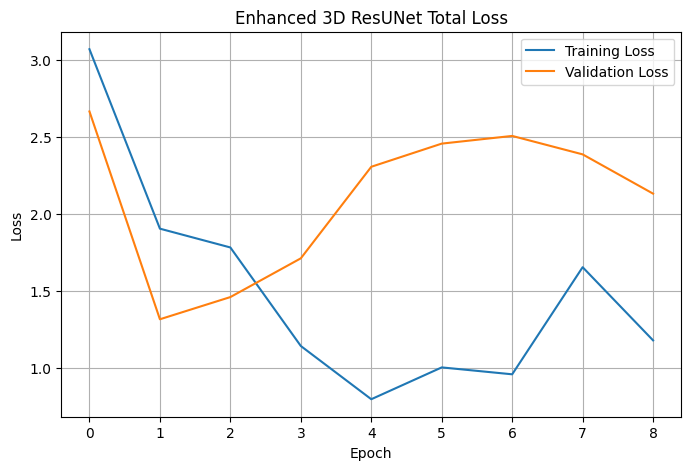

In [30]:
# ============================================================
# CELL 23 — TOTAL LOSS
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Enhanced 3D ResUNet Total Loss")
plt.legend()
plt.grid(True)
plt.show()


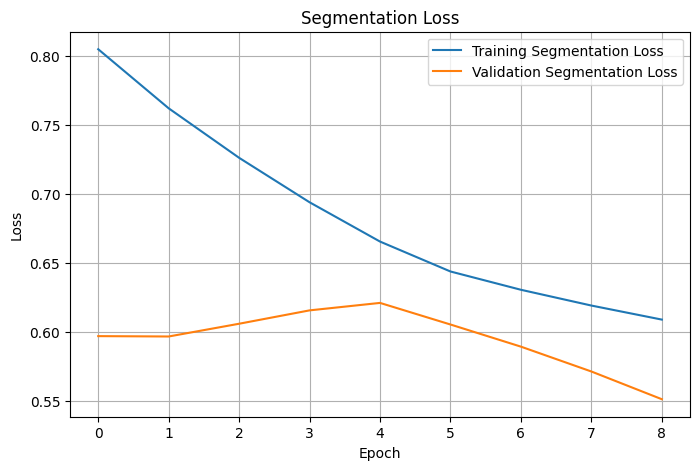

In [31]:
# ============================================================
# CELL 24 — SEGMENTATION LOSS
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(history.history["segmentation_output_loss"], label="Training Segmentation Loss")
plt.plot(history.history["val_segmentation_output_loss"], label="Validation Segmentation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Segmentation Loss")
plt.legend()
plt.grid(True)
plt.show()


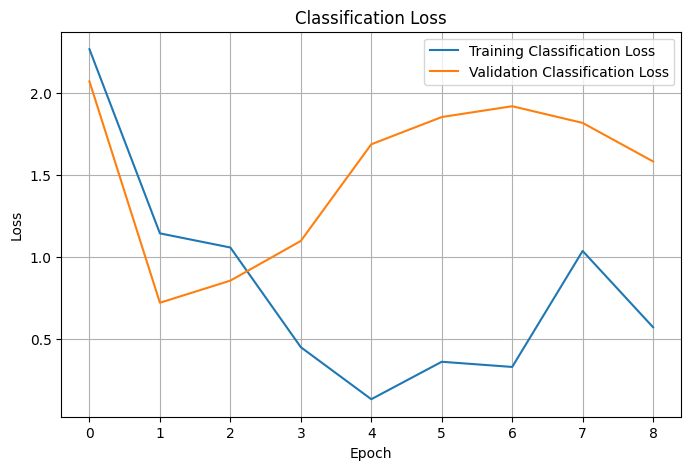

In [32]:
# ============================================================
# CELL 25 — CLASSIFICATION LOSS
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(history.history["classification_output_loss"], label="Training Classification Loss")
plt.plot(history.history["val_classification_output_loss"], label="Validation Classification Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Classification Loss")
plt.legend()
plt.grid(True)
plt.show()


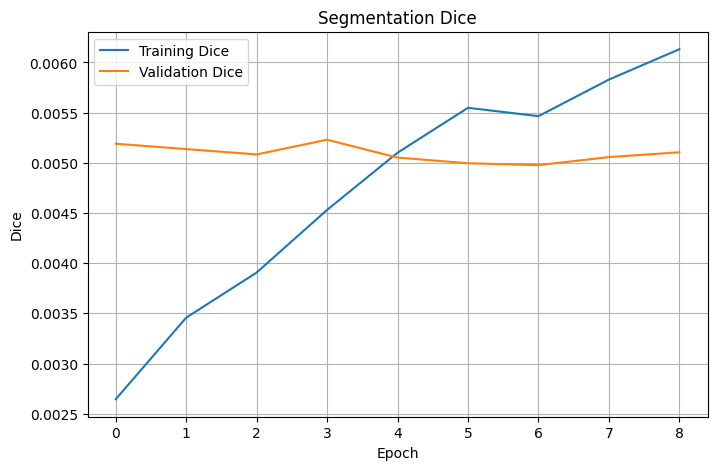

In [33]:
# ============================================================
# CELL 26 — SEGMENTATION DICE
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(history.history["segmentation_output_dice_coefficient"], label="Training Dice")
plt.plot(history.history["val_segmentation_output_dice_coefficient"], label="Validation Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Segmentation Dice")
plt.legend()
plt.grid(True)
plt.show()


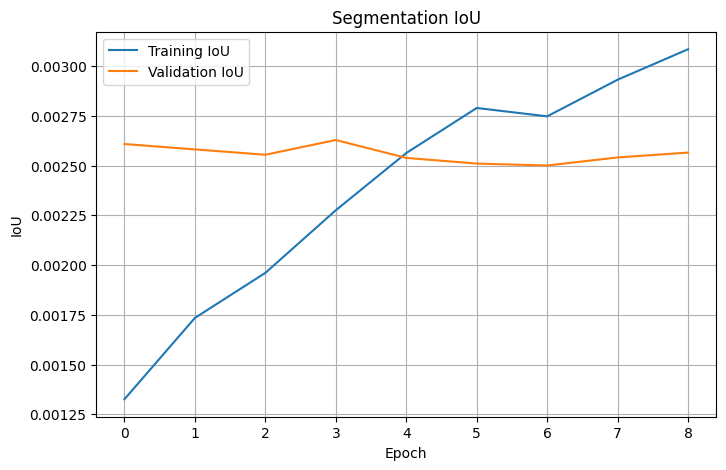

In [34]:
# ============================================================
# CELL 27 — SEGMENTATION IoU
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(history.history["segmentation_output_iou_coefficient"], label="Training IoU")
plt.plot(history.history["val_segmentation_output_iou_coefficient"], label="Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Segmentation IoU")
plt.legend()
plt.grid(True)
plt.show()


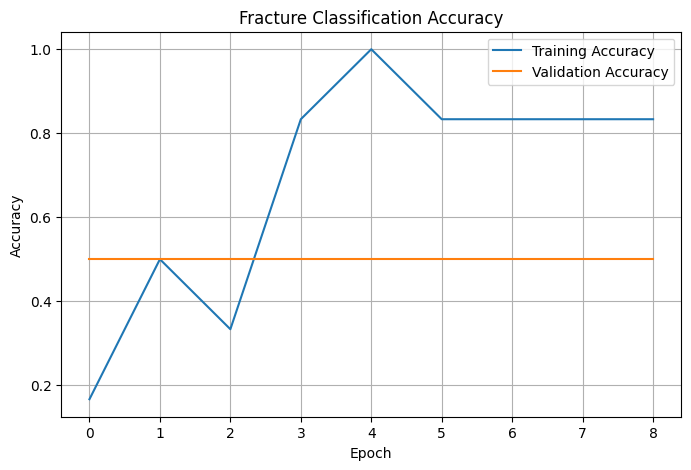

In [35]:
# ============================================================
# CELL 28 — CLASSIFICATION ACCURACY
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(history.history["classification_output_cls_accuracy"], label="Training Accuracy")
plt.plot(history.history["val_classification_output_cls_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fracture Classification Accuracy")
plt.legend()
plt.grid(True)
plt.show()


## 9. Evaluate and save the best model


In [36]:
# ============================================================
# CELL 29 — LOAD BEST MODEL
# ============================================================
best_model = keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={
        "dice_coefficient": dice_coefficient,
        "iou_coefficient": iou_coefficient,
    },
    compile=False,
)

print("Best model loaded successfully.")


Best model loaded successfully.


In [37]:
# ============================================================
# CELL 30 — COMPILE BEST MODEL
# ============================================================
best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss={
        "segmentation_output": keras.losses.BinaryCrossentropy(),
        "classification_output": keras.losses.SparseCategoricalCrossentropy(),
    },
    loss_weights={
        "segmentation_output": SEGMENTATION_LOSS_WEIGHT,
        "classification_output": CLASSIFICATION_LOSS_WEIGHT,
    },
    metrics={
        "segmentation_output": [
            keras.metrics.BinaryAccuracy(name="seg_accuracy"),
            dice_coefficient,
            iou_coefficient,
        ],
        "classification_output": [
            keras.metrics.SparseCategoricalAccuracy(name="cls_accuracy"),
        ],
    },
)

print("Best model compiled.")


Best model compiled.


In [38]:
# ============================================================
# CELL 31 — VALIDATION EVALUATION
# ============================================================
evaluation_results = best_model.evaluate(
    X_val,
    {
        "segmentation_output": Y_seg_val,
        "classification_output": Y_class_val,
    },
    batch_size=BATCH_SIZE,
    return_dict=True,
    verbose=1,
)

print("\nValidation results")
print("=" * 60)
for metric, value in evaluation_results.items():
    print(f"{metric}: {value:.6f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - classification_output_cls_accuracy: 0.5000 - classification_output_loss: 0.7216 - loss: 1.3185 - segmentation_output_dice_coefficient: 0.0051 - segmentation_output_iou_coefficient: 0.0026 - segmentation_output_loss: 0.5969 - segmentation_output_seg_accuracy: 0.6916

Validation results
classification_output_cls_accuracy: 0.500000
classification_output_loss: 0.721574
loss: 1.318462
segmentation_output_dice_coefficient: 0.005137
segmentation_output_iou_coefficient: 0.002582
segmentation_output_loss: 0.596887
segmentation_output_seg_accuracy: 0.691633


In [39]:
# ============================================================
# CELL 32 — SAVE VALIDATION METRICS
# ============================================================
with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump({k: float(v) for k, v in evaluation_results.items()}, f, indent=2)

print("Validation metrics saved:", METRICS_PATH)


Validation metrics saved: /kaggle/working/training_results/validation_metrics.json


In [40]:
# ============================================================
# CELL 33 — SAVE FINAL TRAINED MODEL
# ============================================================
best_model.save(FINAL_MODEL_PATH)
print("Final trained model saved:", FINAL_MODEL_PATH)


Final trained model saved: /kaggle/working/training_results/final_enhanced_3d_resunet_multitask.keras


In [41]:
# ============================================================
# CELL 34 — SAVE EXPERIMENT CONFIGURATION
# ============================================================
experiment_config = {
    "model": "Enhanced_3D_ResUNet_MultiTask",
    "input_shape": [64, 64, 64, 1],
    "patch_size": list(PATCH_SIZE),
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "base_filters": BASE_FILTERS,
    "encoder_depth": DEPTH,
    "dropout_rate": DROPOUT_RATE,
    "batch_size": BATCH_SIZE,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(history.history["loss"]),
    "learning_rate": LEARNING_RATE,
    "optimizer": "Adam",
    "segmentation_loss": "BinaryCrossentropy",
    "classification_loss": "SparseCategoricalCrossentropy",
    "segmentation_loss_weight": SEGMENTATION_LOSS_WEIGHT,
    "classification_loss_weight": CLASSIFICATION_LOSS_WEIGHT,
    "training_patches": int(len(X_train)),
    "validation_patches": int(len(X_val)),
    "seed": SEED,
    "smoke_test_only": bool(SMOKE_TEST_ONLY),
    "patient_level_split_used": bool(USE_FINAL_SPLITS),
}

with open(CONFIG_OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, indent=2)

print("Experiment configuration saved:", CONFIG_OUTPUT_PATH)


Experiment configuration saved: /kaggle/working/training_results/experiment_config.json


## 10. Prepare persistent Kaggle Dataset for Notebook 06

Notebook 06 will consume this complete `training_results` directory. Do not delete or rename the files after training.


In [48]:
# ============================================================
# CELL 35 — CREATE KAGGLE DATASET METADATA
# ============================================================
KAGGLE_METADATA_PATH = OUTPUT_ROOT / "dataset-metadata.json"

training_dataset_metadata = {
    "title": "ribFrac-training-results",
    "id": "waboke/ribfrac-resunet-training-results",
    "licenses": [{"name": "CC-BY-4.0"}],
    "description": (
        "Persistent training artifacts produced by Notebook 05 for the "
        "Enhanced 3D ResUNet multi-task rib fracture segmentation and "
        "five-class classification framework. Includes the best checkpoint, "
        "final trained model, training history, validation metrics, and "
        "experiment configuration for use by Notebook 06."
    ),
}

with open(KAGGLE_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(training_dataset_metadata, f, indent=2)

print("Kaggle metadata created:", KAGGLE_METADATA_PATH)


Kaggle metadata created: /kaggle/working/training_results/dataset-metadata.json


In [49]:
# ============================================================
# CELL 36 — VERIFY ALL NOTEBOOK 06 ARTIFACTS
# ============================================================
required_artifacts = [
    BEST_MODEL_PATH,
    FINAL_MODEL_PATH,
    HISTORY_CSV_PATH,
    HISTORY_NPY_PATH,
    METRICS_PATH,
    CONFIG_OUTPUT_PATH,
    KAGGLE_METADATA_PATH,
]

for path in required_artifacts:
    print(f"{path.exists()!s:5s}  {path}")
    assert path.exists(), f"Missing required artifact: {path}"

print("\nAll required Notebook 06 artifacts are present: PASS")


True   /kaggle/working/training_results/checkpoints/best_enhanced_3d_resunet.keras
True   /kaggle/working/training_results/final_enhanced_3d_resunet_multitask.keras
True   /kaggle/working/training_results/training_history.csv
True   /kaggle/working/training_results/training_history.npy
True   /kaggle/working/training_results/validation_metrics.json
True   /kaggle/working/training_results/experiment_config.json
True   /kaggle/working/training_results/dataset-metadata.json

All required Notebook 06 artifacts are present: PASS


In [50]:
# ============================================================
# CELL 37 — FINAL SUMMARY
# ============================================================
print("=" * 70)
print("NOTEBOOK 05 — TRAINING COMPLETED")
print("=" * 70)
print("Training patches:", len(X_train))
print("Validation patches:", len(X_val))
print("Patient-level split used:", USE_FINAL_SPLITS)
print("Smoke-test only:", SMOKE_TEST_ONLY)
print()
print("Best checkpoint:", BEST_MODEL_PATH)
print("Final model:", FINAL_MODEL_PATH)
print("Training history:", HISTORY_CSV_PATH)
print("Validation metrics:", METRICS_PATH)
print("Kaggle metadata:", KAGGLE_METADATA_PATH)
print()
print("Publish this directory as:")
print("waboke/ribfrac-resunet-training-results")
print("=" * 70)


NOTEBOOK 05 — TRAINING COMPLETED
Training patches: 6
Validation patches: 2
Patient-level split used: False
Smoke-test only: True

Best checkpoint: /kaggle/working/training_results/checkpoints/best_enhanced_3d_resunet.keras
Final model: /kaggle/working/training_results/final_enhanced_3d_resunet_multitask.keras
Training history: /kaggle/working/training_results/training_history.csv
Validation metrics: /kaggle/working/training_results/validation_metrics.json
Kaggle metadata: /kaggle/working/training_results/dataset-metadata.json

Publish this directory as:
waboke/ribfrac-resunet-training-results


In [51]:
# ============================================================
# VERIFY TRAINING RESULTS BEFORE PERSISTING
# ============================================================

from pathlib import Path

TRAINING_RESULTS_ROOT = Path(
    "/kaggle/working/training_results"
)

print("Training results directory:")
print(TRAINING_RESULTS_ROOT)
print()

for path in sorted(TRAINING_RESULTS_ROOT.rglob("*")):
    if path.is_file():
        size_mb = path.stat().st_size / (1024 ** 2)

        print(
            f"{path.relative_to(TRAINING_RESULTS_ROOT)}"
            f"    {size_mb:.2f} MB"
        )

Training results directory:
/kaggle/working/training_results

checkpoints/best_enhanced_3d_resunet.keras    83.33 MB
dataset-metadata.json    0.00 MB
experiment_config.json    0.00 MB
final_enhanced_3d_resunet_multitask.keras    27.99 MB
training_history.csv    0.00 MB
training_history.npy    0.00 MB
validation_metrics.json    0.00 MB


In [52]:
# ============================================================
# VERIFY KAGGLE DATASET METADATA
# ============================================================

import json
from pathlib import Path

METADATA_PATH = Path(
    "/kaggle/working/training_results/dataset-metadata.json"
)

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

print("Kaggle dataset metadata:")
print(json.dumps(metadata, indent=4))

Kaggle dataset metadata:
{
    "title": "ribFrac-training-results",
    "id": "waboke/ribfrac-resunet-training-results",
    "licenses": [
        {
            "name": "CC-BY-4.0"
        }
    ],
    "description": "Persistent training artifacts produced by Notebook 05 for the Enhanced 3D ResUNet multi-task rib fracture segmentation and five-class classification framework. Includes the best checkpoint, final trained model, training history, validation metrics, and experiment configuration for use by Notebook 06."
}


In [54]:
# ============================================================
# PUBLISH TRAINING RESULTS AS KAGGLE DATASET
# ============================================================

!kaggle datasets create \
    -p /kaggle/working/training_results

Starting upload for file validation_metrics.json
100%|██████████████████████████████████████████| 363/363 [00:00<00:00, 1.21kB/s]
Upload successful: validation_metrics.json (363B)
Starting upload for file final_enhanced_3d_resunet_multitask.keras
100%|██████████████████████████████████████| 28.0M/28.0M [00:00<00:00, 57.3MB/s]
Upload successful: final_enhanced_3d_resunet_multitask.keras (28MB)
Skipping folder: checkpoints; use '--dir-mode' to upload folders
Starting upload for file training_history.csv
100%|██████████████████████████████████████| 2.90k/2.90k [00:00<00:00, 9.93kB/s]
Upload successful: training_history.csv (3KB)
Starting upload for file experiment_config.json
100%|██████████████████████████████████████████| 793/793 [00:00<00:00, 2.80kB/s]
Upload successful: experiment_config.json (793B)
Starting upload for file training_history.npy
100%|██████████████████████████████████████| 1.97k/1.97k [00:00<00:00, 6.98kB/s]
Upload successful: training_history.npy (2KB)
Your private Da